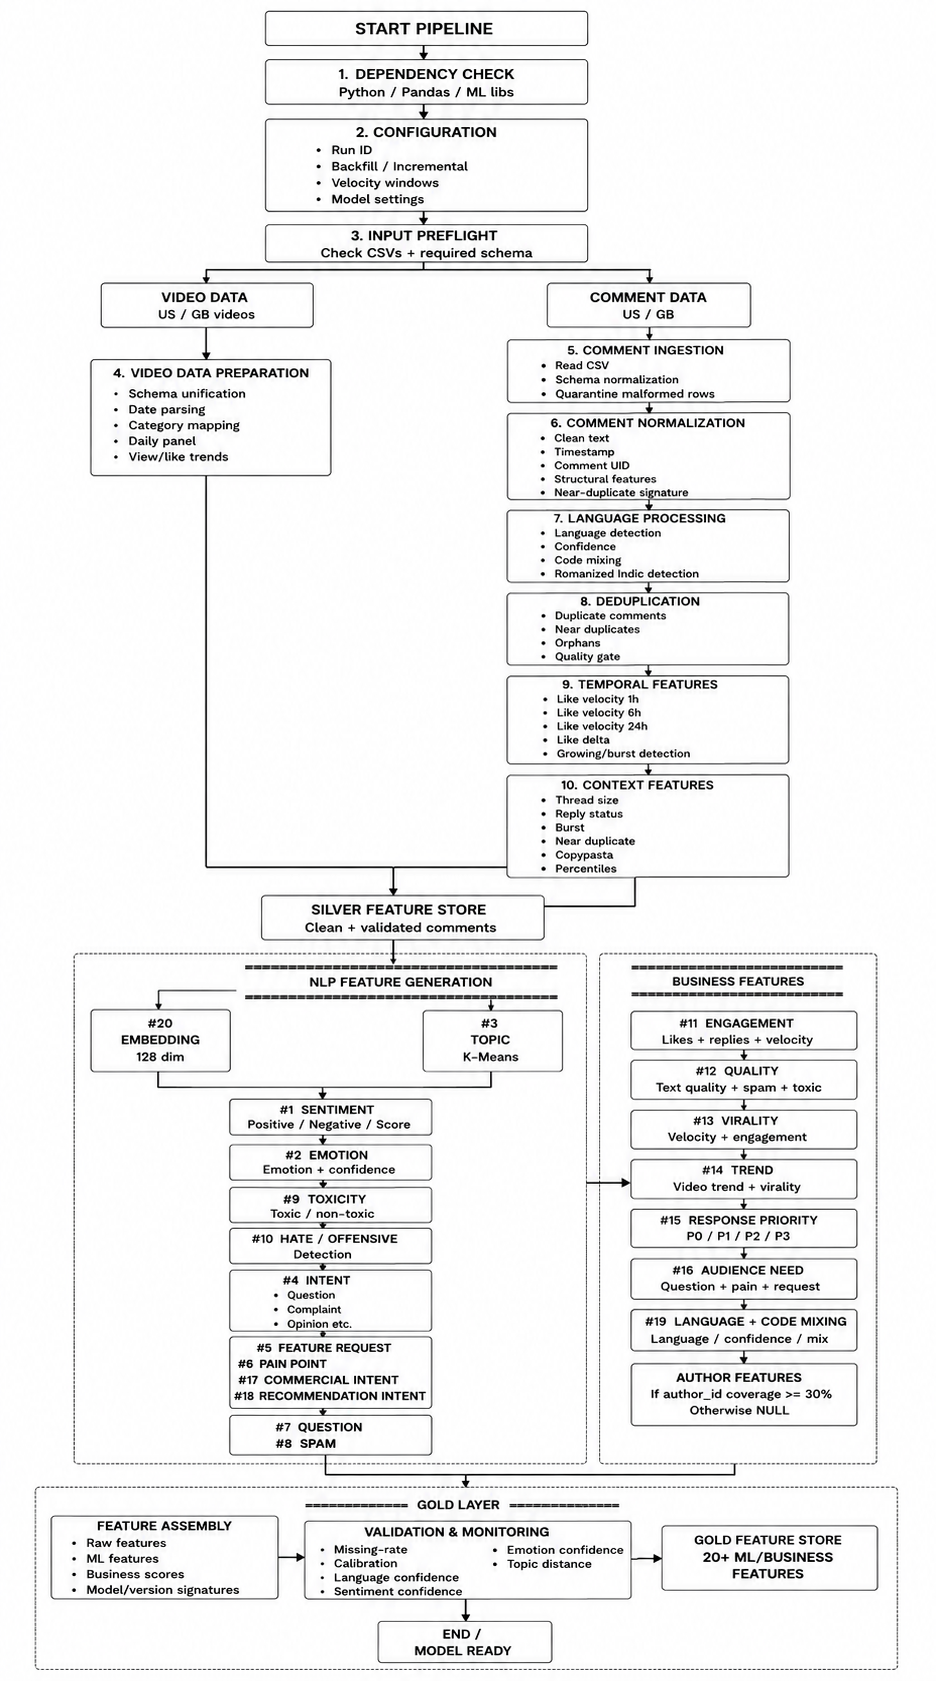
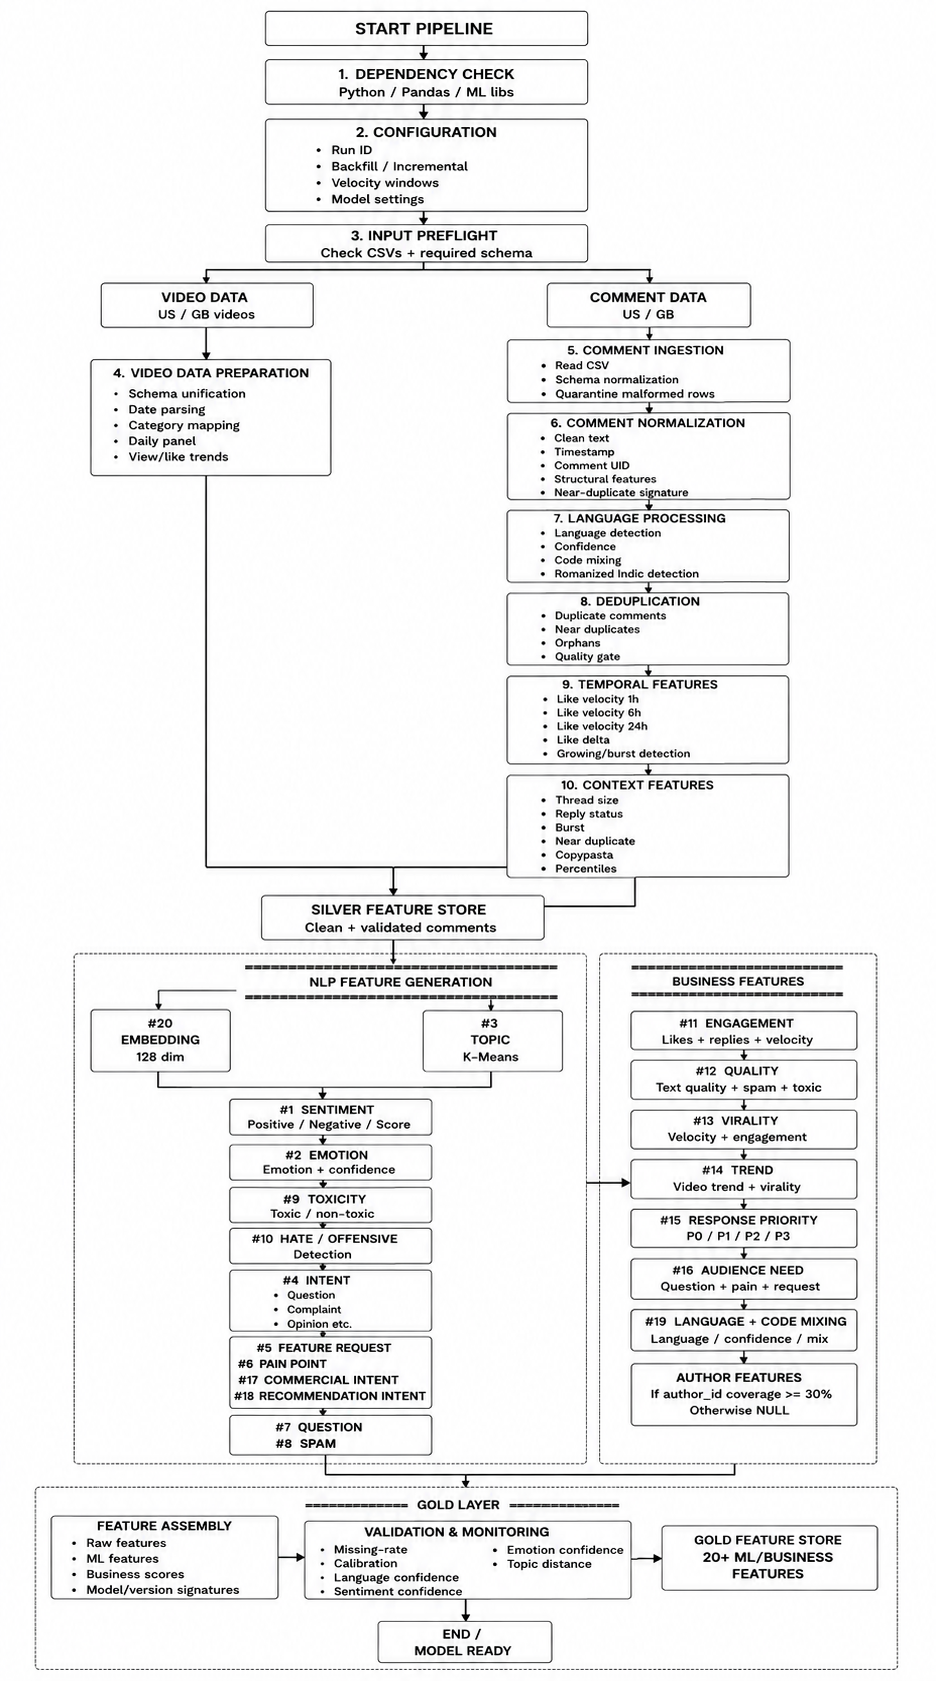

In [1]:
import importlib.util as _u
_need=[('pandas','pandas'),('numpy','numpy'),('pyarrow','pyarrow'),('sklearn','scikit-learn'),
       ('lingua','lingua-language-detector')]
_missing=[pip for mod,pip in _need if _u.find_spec(mod) is None]
if _missing:
    import subprocess,sys
    subprocess.run([sys.executable,'-m','pip','install','-q',*_missing])
# Optional real model heads (big download, GPU recommended):
#   pip install -q transformers sentence-transformers torch
print('deps ok', 'installed:'+','.join(_missing) if _missing else '(all present)')

deps ok (all present)


In [2]:
#####Cell 2 — config + versions (CHANGED: v1.1.0, velocity windows, author/near-dup/copypasta knobs, env sig, split-store dirs)

import os, re, csv, json, sys, math, hashlib, unicodedata, warnings, pickle, platform
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import sklearn

warnings.filterwarnings("ignore")
csv.field_size_limit(10_000_000)

class CFG:
    DATA_DIR = os.environ.get("DATA_DIR")
    CANDIDATES = ["/kaggle/input/youtube-new","/kaggle/working",
                  "/Trending-YouTube-Scraper/output","/mnt/user-data/uploads","./fixture","./data","."]
    FILES = {
        "videos":   {"US":"USvideos.csv",        "GB":"GBvideos.csv"},
        "comments": {"US":"UScomments.csv",      "GB":"GBcomments.csv"},
        "category": {"US":"US_category_id.json", "GB":"GB_category_id.json"},
    }
    STORE = Path(os.environ.get("CI_STORE", "./feature_store"))
    RUN_MODE      = os.environ.get("RUN_MODE","backfill")
    WINDOW_HOURS  = 24
    VELOCITY_WINDOWS = (1,6,24)          # NEW: real windowed velocity (P0-2)
    DEFAULT_YEAR  = 2017
    TZ            = "UTC"
    MIN_CHARS     = 2
    MAX_CHARS     = 5000
    KEEP_QUARANTINE = True

    PIPELINE_VERSION = "1.1.0"
    SCHEMA_VERSION   = "1.1.0"
    FEATURE_VERSION  = "1.1.0"
    MODEL_VERSION    = "1.1.0"

    USE_MODELS   = os.environ.get("USE_MODELS","auto")
    EMB_MODEL    = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    SENTIMENT_MODEL = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
    EMOTION_MODEL   = "j-hartmann/emotion-english-distilroberta-base"
    TOXIC_MODEL     = "unitary/toxic-bert"
    HATE_MODEL      = "cardiffnlp/twitter-roberta-base-hate-latest"
    ZEROSHOT_MODEL  = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
    N_TOPICS     = 24
    BATCH        = 256
    # NEW: author features only trusted above this author_id coverage (P2-10)
    AUTHOR_MIN_COVERAGE = 0.30
    NEAR_DUP_MIN_WORDS  = 4      # near-dup signature ignores ultra-short text (P2-13)
    COPYPASTA_MIN_VIDEOS = 2     # same signature across >=N videos => copypasta

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
RUN_TS = datetime.now(timezone.utc)
FIT_MODE = (CFG.RUN_MODE == "backfill")
ENV_SIG = {"python":platform.python_version(),"pandas":pd.__version__,
           "numpy":np.__version__,"sklearn":sklearn.__version__}

for sub in ["bronze/videos_daily","bronze/comments","silver/comments","silver/videos_daily",
            "gold/comments_features","gold/embeddings","gold/raw_features","gold/ml_features",
            "gold/business_scores","quarantine","models","meta","_state"]:
    (CFG.STORE/sub).mkdir(parents=True, exist_ok=True)

In [3]:
#Cell 3 —  inputs + preflight (find the data dir, assert every file exists)
def resolve_data_dir():
    probe = CFG.FILES["videos"]["US"]
    if CFG.DATA_DIR:
        root=Path(CFG.DATA_DIR); assert (root/probe).exists(), f"{root} lacks {probe}"; return root
    for c in CFG.CANDIDATES:
        if (Path(c)/probe).exists(): return Path(c)
    for c in CFG.CANDIDATES:
        hits=list(Path(c).rglob(probe)) if Path(c).exists() else []
        if hits: return hits[0].parent
    raise FileNotFoundError(f"{probe} not found; set CFG.DATA_DIR")

INPUT_ROOT = resolve_data_dir()
PATHS, missing = {}, []
for kind, per in CFG.FILES.items():
    for cc,fname in per.items():
        p=INPUT_ROOT/fname; PATHS.setdefault(kind,{})[cc]=p
        if not p.exists(): missing.append(str(p))
if missing: raise FileNotFoundError("missing inputs:\n  "+"\n  ".join(missing))
print(f"[cfg] input={INPUT_ROOT} store={CFG.STORE} run_id={RUN_ID} mode={CFG.RUN_MODE} fit={FIT_MODE}")

[cfg] input=. store=feature_store run_id=20260903T130134Z mode=backfill fit=True


In [4]:
#Cell 4 — optional debug: peek at input columns
import pandas as _pd
for _cc,_p in PATHS['videos'].items():
    _h=_pd.read_csv(_p, nrows=3, on_bad_lines='skip')
    print(_cc, _p.name, '->', list(_h.columns)[:8])

US USvideos.csv -> ['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views', 'likes', 'dislikes']
GB GBvideos.csv -> ['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views', 'likes', 'dislikes']


In [5]:
#Cell 5 — CSV reader + rich quarantine (malformed rows are captured with reason, not silently dropped)

def read_csv_quarantine(path, expected_cols=None, kind=None, country=None, encoding="utf-8"):
    good, bad = [], []
    fname = Path(path).name
    with open(path,"r",encoding=encoding,errors="replace",newline="") as fh:
        reader=csv.reader(fh); header=[h.strip().lstrip("\ufeff") for h in next(reader)]; n=len(header)
        for lineno,row in enumerate(reader,start=2):
            if len(row)==n: good.append(row)
            else:
                bad.append({"bad_row_reason":f"expected {n} fields, saw {len(row)}","source_line_number":lineno,
                            "n_fields":len(row),"source_file":fname,"kind":kind,"country":country,
                            "ingestion_run_id":RUN_ID,"raw":",".join(row)[:500]})
    df=pd.DataFrame(good, columns=header, dtype="object")
    if expected_cols:
        miss=set(expected_cols)-set(df.columns); assert not miss, f"{path}: missing {miss}"
    return df, pd.DataFrame(bad)

In [6]:
# Cell 6 — schema unification + extended comment schema (legacy vs modern video CSVs; optional prod comment columns) 

VIDEO_SCHEMAS = {
    "legacy": {"video_id":"video_id","title":"title","channel_title":"channel_title",
               "category_id":"category_id","tags":"tags","views":"views","likes":"likes",
               "dislikes":"dislikes","comment_total":"comment_count","thumbnail_link":"thumbnail_link",
               "date":"trending_date_raw"},
    "modern": {"video_id":"video_id","title":"title","channelTitle":"channel_title","channelId":"channel_id",
               "categoryId":"category_id","tags":"tags","view_count":"views","likes":"likes","dislikes":"dislikes",
               "comment_count":"comment_count","thumbnail_link":"thumbnail_link","trending_date":"trending_date_raw",
               "publishedAt":"published_at_raw","description":"description",
               "comments_disabled":"comments_disabled","ratings_disabled":"ratings_disabled"},
}
COMMENT_SCHEMA = {"video_id":"video_id","comment_text":"text_raw","likes":"c_likes","replies":"c_replies"}
COMMENT_SCHEMA_OPTIONAL = {
    "comment_id":"comment_id","commentId":"comment_id","id":"comment_id",
    "author_id":"author_id","authorId":"author_id","authorChannelId":"author_id",
    "published_at":"comment_published_at","publishedAt":"comment_published_at",
    "updated_at":"comment_updated_at","updatedAt":"comment_updated_at",
    "parent_comment_id":"parent_comment_id","parentId":"parent_comment_id",
}
OPTIONAL_COMMENT_COLS = ["comment_id","author_id","comment_published_at","comment_updated_at","parent_comment_id"]

def detect_schema(cols):
    cols=set(cols)
    if {"view_count","trending_date"} & cols: return "modern"
    if {"views","date"} <= cols: return "legacy"
    raise ValueError(f"unknown video schema: {sorted(cols)[:12]}")

In [7]:
#Cell 7 — date parsing + comment-timestamp hook (handles %y.%d.%m legacy + ISO modern; year-wrap guard)

In [8]:
def parse_trending_date(s, schema, default_year=CFG.DEFAULT_YEAR):
    s=s.astype(str).str.strip()
    if schema=="modern":
        iso=pd.to_datetime(s, format="%Y-%m-%dT%H:%M:%S%z", errors="coerce", utc=True)
        dotted=pd.to_datetime(s, format="%y.%d.%m", errors="coerce", utc=True)
        return iso.fillna(dotted)
    d=pd.to_datetime(s+f".{default_year}", format="%d.%m.%Y", errors="coerce", utc=True)
    if d.notna().any():
        months=d.dt.month.dropna()
        if len(months) and months.max()-months.min()>6:
            wrap=d.dt.month < months.max()-6
            d=d.mask(wrap, d+pd.offsets.DateOffset(years=1))
    return d

def parse_comment_ts(series):
    if series is None: return None
    return pd.to_datetime(series, errors="coerce", utc=True)

In [9]:
#Cell 8 — normalise + structural features + swappable UID + near-dup signature (CHANGED: adds near_dup_signature)
CTRL_RE=re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")
WS_RE=re.compile(r"\s+")
URL_RE=re.compile(r"(https?://\S+|www\.\S+|\b\S+\.(?:com|net|org|ly|be|io|in)\b/?\S*)", re.I)
MENTION_RE=re.compile(r"@[\w.\-]{2,}")
HASHTAG_RE=re.compile(r"#\w+")
TIMECODE_RE=re.compile(r"\b\d{1,2}:\d{2}(?::\d{2})?\b")
REPEAT_PUNCT_RE=re.compile(r"([!?.,])\1{1,}")
ELONG_RE=re.compile(r"([A-Za-z])\1{2,}")
EMOJI_RE=re.compile("[\U0001F000-\U0001FAFF\U00002600-\U000027BF\U0001F1E6-\U0001F1FF"
                    "\U00002190-\U000021FF\U00002B00-\U00002BFF\U0000FE0F\U00002700-\U000027BF]")
SCRIPTS={"latin":re.compile(r"[A-Za-z]"),"devanagari":re.compile(r"[\u0900-\u097F]"),
         "bengali":re.compile(r"[\u0980-\u09FF]"),"arabic":re.compile(r"[\u0600-\u06FF]"),
         "cjk":re.compile(r"[\u4E00-\u9FFF\u3040-\u30FF\uAC00-\uD7AF]"),"cyrillic":re.compile(r"[\u0400-\u04FF]")}

def normalise_text(s):
    s=s.fillna("").astype(str).map(lambda x:unicodedata.normalize("NFKC",x))
    s=s.str.replace(CTRL_RE," ",regex=True).str.replace(r"\\n|\\r"," ",regex=True)
    s=s.str.replace(WS_RE," ",regex=True).str.strip()
    return s.str.slice(0,CFG.MAX_CHARS).astype(object)

def structural_stats(raw, clean):
    raw,clean=raw.astype(object),clean.astype(object)
    out=pd.DataFrame(index=raw.index)
    n=clean.str.len().astype("int32"); out["char_len"]=n
    out["word_len"]=clean.str.split().map(len).astype("int32")
    out["n_urls"]=clean.str.count(URL_RE).astype("int16")
    out["n_mentions"]=clean.str.count(MENTION_RE).astype("int16")
    out["n_hashtags"]=clean.str.count(HASHTAG_RE).astype("int16")
    out["n_timecodes"]=clean.str.count(TIMECODE_RE).astype("int16")
    out["n_emoji"]=raw.str.count(EMOJI_RE).astype("int16")
    out["n_question_marks"]=clean.str.count(r"\?").astype("int16")
    out["ends_question"]=clean.str.rstrip(" .!").str.endswith("?").fillna(False)
    out["n_repeat_punct"]=clean.str.count(REPEAT_PUNCT_RE).astype("int16")
    out["n_elongations"]=clean.str.count(ELONG_RE).astype("int16")
    letters=clean.str.count(r"[A-Za-z]").replace(0,np.nan)
    out["upper_ratio"]=(clean.str.count(r"[A-Z]")/letters).fillna(0).astype("float32")
    out["digit_ratio"]=(clean.str.count(r"\d")/n.replace(0,np.nan)).fillna(0).astype("float32")
    out["emoji_ratio"]=(out["n_emoji"]/n.replace(0,np.nan)).fillna(0).astype("float32")
    for name,rx in SCRIPTS.items():
        out[f"script_{name}"]=(clean.str.count(rx)/n.replace(0,np.nan)).fillna(0).astype("float32")
    out["is_degenerate"]=(n<CFG.MIN_CHARS)|(out["word_len"]==0)
    return out

def comment_uid(df):
    have_id = "comment_id" in df.columns and df["comment_id"].notna().any()
    if have_id:
        cid=df["comment_id"].astype("string")
        need=cid.isna()
        fallback=(df["video_id"].astype(str)+"\x1f"+df["country"].astype(str)+"\x1f"+df["text_clean"].astype(str))
        cid=cid.mask(need, fallback.map(lambda k:"h:"+hashlib.blake2b(k.encode(),digest_size=8).hexdigest()))
        return cid.astype(object)
    key=df["video_id"].astype(str)+"\x1f"+df["country"].astype(str)+"\x1f"+df["text_clean"].astype(str)
    return key.map(lambda k:hashlib.blake2b(k.encode(),digest_size=8).hexdigest())

# NEW: near-duplicate signature (P2-13) — case/punct/emoji-insensitive shingle of sorted unique tokens
_ALNUM_RE=re.compile(r"[^a-z0-9\u0900-\u097F\u0980-\u09FF ]+")
def near_dup_signature(clean):
    def sig(t):
        t=_ALNUM_RE.sub(" ", (t or "").lower())
        toks=[w for w in t.split() if w]
        if len(toks)<CFG.NEAR_DUP_MIN_WORDS: return ""      # too short to fingerprint
        uniq=sorted(set(toks))
        return hashlib.blake2b((" ".join(uniq)).encode(),digest_size=8).hexdigest()
    return clean.map(sig).astype(object)


In [10]:
# Cell 9 — language + code-mixing head #19 (CHANGED: romanised-Indic markers for Hinglish/Banglish )
# romanised-Indic marker lexicon — lingua has no transliterated-Hindi/Bengali model, so Latin-script
# Hinglish/Banglish reads as a low-confidence European language. These distinctive tokens are a
# documented heuristic that recovers code-mixing lingua alone misses (review P1-8).
ROMAN_INDIC=set("""
bhai bhaiya yaar hai hain ye yeh woh kya kyun kaise kaisa kahan kaun kab kitne kitna nahi nahin
mat matlab acha accha achha badhiya shandaar mast bakwaas bekar ganda paisa kaam banao banaao
aayega aygaa dekho dekhna chahiye zabardast bahut thoda bohot maza pyaar bhaut sahi galat
dada bhalo khub sundor sundar hoyeche kemon ache tumi ami valo daruntumi bhai
""".split())

class LangHead:
    def __init__(self):
        self.det=None
        try:
            from lingua import LanguageDetectorBuilder
            self.det=LanguageDetectorBuilder.from_all_languages().with_preloaded_language_models().build()
            self._ok=True
        except Exception as e:
            self._ok=False; self._why=str(e)
    def run(self, texts, script_latin):
        n=len(texts)
        lang=np.array(["und"]*n,dtype=object); conf=np.zeros(n,dtype="float32"); mixed=np.zeros(n,dtype=bool)
        if not self._ok:
            for i,sl in enumerate(script_latin):
                lang[i]="en" if sl>0.5 else "non-latin"; conf[i]=0.3
            return lang,conf,mixed
        for i,t in enumerate(texts):
            t=(t or "").strip()
            if len(t)<3: continue
            vals=self.det.compute_language_confidence_values(t)
            if not vals: continue
            top=vals[0]; lang[i]=top.language.iso_code_639_1.name.lower(); conf[i]=float(top.value)
            strong=[v for v in vals if v.value>=0.35]
            toks=t.lower().split(); wl=len(toks)
            indic_markers=sum(tok in ROMAN_INDIC for tok in toks)
            # (a) two confident languages, or (b) confident non-English Latin, or (c) romanised-Indic markers
            romanised=(script_latin[i]>0.6 and lang[i]!="en" and conf[i]>=0.55 and wl>=3)
            roman_indic=(script_latin[i]>0.6 and indic_markers>=1 and wl>=3)
            mixed[i]=(len(strong)>=2) or romanised or roman_indic
            if roman_indic and (conf[i]<0.6 or lang[i]!="en"):
                lang[i]="hi-en"; conf[i]=max(conf[i],0.55)   # romanised code-mix tag + positive signal
        return lang,conf,mixed

In [11]:
#Cell 10 — category maps (category_id → title per country)
def load_category_maps(paths):
    m={}
    for cc,p in paths["category"].items():
        payload=json.loads(Path(p).read_text())
        m[cc]={int(it["id"]):it["snippet"]["title"] for it in payload.get("items",[])}
    return m

In [12]:
#Cell 11 — load videos (schema-detect, coerce numerics, attach category, parse tags)
def load_videos(PATHS, CAT_MAPS, quarantine):
    vid_parts=[]
    for cc,f in sorted(PATHS["videos"].items()):
        df,bad=read_csv_quarantine(str(f),kind="videos",country=cc)
        schema=detect_schema(df.columns); df=df.rename(columns=VIDEO_SCHEMAS[schema])
        df=df[[c for c in set(VIDEO_SCHEMAS[schema].values()) if c in df.columns]].copy()
        df["country"],df["schema"],df["source_file"]=cc,schema,f.name
        df["trending_ts"]=parse_trending_date(df["trending_date_raw"],schema)
        if len(bad): quarantine.append(bad)
        vid_parts.append(df)
        print(f"   {f.name:<22} cc={cc} schema={schema:<6} rows={len(df):>6,} bad={len(bad):>3}")
    videos=pd.concat(vid_parts,ignore_index=True)
    for c in ["views","likes","dislikes","comment_count"]:
        if c in videos.columns: videos[c]=pd.to_numeric(videos[c],errors="coerce").astype("Int64")
    videos["category_id"]=pd.to_numeric(videos["category_id"],errors="coerce").astype("Int64")
    videos["category_name"]=[CAT_MAPS.get(cc,{}).get(int(ci)) if pd.notna(ci) else None
                             for cc,ci in zip(videos["country"],videos["category_id"])]
    videos["dt"]=videos["trending_ts"].dt.strftime("%Y-%m-%d")
    videos["tag_list"]=(videos["tags"].fillna("[none]").str.replace('"',"",regex=False)
                        .str.split("|").map(lambda t:[x.strip() for x in t if x.strip() and x!="[none]"]))
    videos["n_tags"]=videos["tag_list"].map(len).astype("int16")
    return videos


In [13]:
#Cell 12 — daily panel + multi-window deltas (dedup per video-day, 24h/3d/7d diffs, engagement rates)
def daily_panel(videos):
    num_cols=[c for c in ["views","likes","dislikes","comment_count"] if c in videos.columns]
    videos=(videos.sort_values(["country","video_id","trending_ts"])
                  .drop_duplicates(subset=["country","video_id","dt"],keep="last").reset_index(drop=True))
    g=videos.groupby(["country","video_id"],sort=False)
    for c in num_cols: videos[f"{c}_d24"]=g[c].diff().astype("Int64")
    videos["day_index"]=g.cumcount().astype("int16")
    for w in (3,7):
        for c in num_cols:
            videos[f"{c}_d{w}d"]=(g[c].transform(lambda s:s-s.shift(w))).astype("Int64")
    if "views" in videos: videos["views_velocity_h"]=(videos["views_d24"].astype("float32")/24.0).astype("float32")
    videos["engagement_rate"]=((videos["likes"].fillna(0)+videos["comment_count"].fillna(0))
                               /videos["views"].replace(0,np.nan)).astype("float32")
    videos["like_ratio"]=(videos["likes"]/(videos["likes"]+videos["dislikes"]).replace(0,np.nan)).astype("float32")
    print(f"[vid] panel {len(videos):,} rows | {videos.video_id.nunique():,} videos | "
          f"{videos.dt.nunique()} days {videos.dt.min()}->{videos.dt.max()}")
    return videos


In [14]:
#Cell 13 — load comments + optional prod fields + observation time (CHANGED: parses updated_at → comment_updated_ts)
def load_comments(PATHS, quarantine, lang_head):
    cmt_parts=[]
    for cc,f in sorted(PATHS["comments"].items()):
        df,bad=read_csv_quarantine(str(f),kind="comments",country=cc)
        ren={**COMMENT_SCHEMA}
        for src,canon in COMMENT_SCHEMA_OPTIONAL.items():
            if src in df.columns: ren[src]=canon
        df=df.rename(columns=ren)
        df["country"],df["source_file"]=cc,f.name
        for col in OPTIONAL_COMMENT_COLS:
            if col not in df.columns: df[col]=pd.NA
        if len(bad): quarantine.append(bad)
        cmt_parts.append(df); print(f"   {f.name:<22} cc={cc} rows={len(df):>8,} bad={len(bad):>3}")
    comments=pd.concat(cmt_parts,ignore_index=True); n_raw=len(comments)
    comments["c_likes"]=pd.to_numeric(comments["c_likes"],errors="coerce").fillna(0).astype("int32")
    comments["c_replies"]=pd.to_numeric(comments["c_replies"],errors="coerce").fillna(0).astype("int32")
    comments["text_raw"]=comments["text_raw"].fillna("")
    comments["text_clean"]=normalise_text(comments["text_raw"])
    comments["comment_published_ts"]=parse_comment_ts(comments.get("comment_published_at"))
    comments["comment_updated_ts"]=parse_comment_ts(comments.get("comment_updated_at"))   # NEW: observation time
    comments["comment_uid"]=comment_uid(comments)
    sl=comments["text_clean"].astype(object).str.count(SCRIPTS["latin"]) / \
       comments["text_clean"].str.len().replace(0,np.nan)
    sl=sl.fillna(0).to_numpy()
    lang,conf,mixed=lang_head.run(comments["text_clean"].tolist(), sl)
    comments["language"]=lang; comments["language_confidence"]=conf; comments["is_code_mixed"]=mixed
    return comments, n_raw


In [15]:
#Cell 14 — attach event time + observation time (CHANGED: adds observed_ts = when a like/reply count was seen)

In [16]:
def attach_event_time(comments, videos):
    comments=comments.drop(columns=["video_first_ts"],errors="ignore")
    first_seen=(videos.groupby(["country","video_id"],as_index=False)["trending_ts"].min()
                      .rename(columns={"trending_ts":"video_first_ts"}))
    comments=comments.merge(first_seen,on=["country","video_id"],how="left")
    assert "video_first_ts" in comments.columns
    comments["event_ts_source"]=np.where(comments["comment_published_ts"].notna(),"comment_published","video_first_seen")
    comments["event_ts"]=comments["comment_published_ts"].fillna(comments["video_first_ts"])
    # NEW: observation time = when this like/reply count was seen (updated_at > published > video_first > run_ts)
    obs=comments["comment_updated_ts"].fillna(comments["comment_published_ts"]).fillna(comments["video_first_ts"])
    comments["observed_ts"]=obs.fillna(pd.Timestamp(RUN_TS))
    comments["observed_ts_source"]=np.select(
        [comments["comment_updated_ts"].notna(),comments["comment_published_ts"].notna(),comments["video_first_ts"].notna()],
        ["comment_updated","comment_published","video_first_seen"], default="run_ts")
    orphans=int(comments["event_ts"].isna().sum())
    comments=comments[comments["event_ts"].notna()].copy()
    return comments, orphans

In [17]:
#Cell 15 — dedup + trajectory + REAL windowed velocity 

def _windowed_velocity(comments, windows=CFG.VELOCITY_WINDOWS):
    """Real per-window deltas from the like/reply trajectory. For each comment_uid,
    velocity_wh = (metric_last - metric_at_or_after(t_last - w h)) / elapsed_hours.
    NaN when no earlier observation falls inside that window (honestly unknown)."""
    idx_uid=[]; data={f"like_velocity_{w}h":[] for w in windows}
    data.update({f"reply_velocity_{w}h":[] for w in windows})
    data["n_observations"]=[]; data["observed_span_h"]=[]
    sub=comments[["comment_uid","observed_ts","c_likes","c_replies"]].sort_values(["comment_uid","observed_ts"])
    for uid,g in sub.groupby("comment_uid",sort=False):
        ts=g["observed_ts"].to_numpy(); lk=g["c_likes"].to_numpy(); rp=g["c_replies"].to_numpy()
        t_last=ts[-1]; lk_last=lk[-1]; rp_last=rp[-1]
        idx_uid.append(uid); data["n_observations"].append(len(g))
        data["observed_span_h"].append(max((t_last-ts[0])/np.timedelta64(1,"h"),0.0))
        for w in windows:
            cutoff=t_last-np.timedelta64(int(w),"h"); mask=ts>=cutoff
            lv=rv=np.nan
            if mask.any():
                i0=int(np.argmax(mask)); elapsed=(t_last-ts[i0])/np.timedelta64(1,"h")
                if elapsed>0:
                    lv=(lk_last-lk[i0])/elapsed; rv=(rp_last-rp[i0])/elapsed
            data[f"like_velocity_{w}h"].append(lv); data[f"reply_velocity_{w}h"].append(rv)
    out=pd.DataFrame(data, index=pd.Index(idx_uid,name="comment_uid"))
    for c in out.columns:
        out[c]=out[c].astype("float32") if c!="n_observations" else out[c].astype("int32")
    return out.reset_index()

def dedup_trajectory(comments):
    comments=comments.sort_values(["comment_uid","observed_ts","c_likes"])
    agg=(comments.groupby("comment_uid",sort=False)
         .agg(video_id=("video_id","first"),country=("country","first"),
              comment_id=("comment_id","first"),author_id=("author_id","first"),
              parent_comment_id=("parent_comment_id","first"),
              text_raw=("text_raw","first"),text_clean=("text_clean","first"),
              language=("language","first"),language_confidence=("language_confidence","first"),
              is_code_mixed=("is_code_mixed","first"),
              likes_first=("c_likes","first"),likes_last=("c_likes","last"),likes_max=("c_likes","max"),
              replies_first=("c_replies","first"),replies_last=("c_replies","last"),replies_max=("c_replies","max"),
              event_ts=("event_ts","min"),event_ts_last=("event_ts","max"),
              observed_ts=("observed_ts","min"),observed_ts_last=("observed_ts","max"),
              event_ts_source=("event_ts_source","first"),observed_ts_source=("observed_ts_source","first"))
         .reset_index())
    agg["likes_delta"]=(agg["likes_last"]-agg["likes_first"]).astype("int32")
    agg["replies_delta"]=(agg["replies_last"]-agg["replies_first"]).astype("int32")
    agg["is_growing"]=agg["likes_delta"]>0
    # coarse overall velocity over the full observed span (kept as a robust fallback)
    span_h=((agg["observed_ts_last"]-agg["observed_ts"]).dt.total_seconds()/3600.0).clip(lower=1.0)
    agg["like_velocity"]=(agg["likes_delta"]/span_h).astype("float32")
    agg["reply_velocity"]=(agg["replies_delta"]/span_h).astype("float32")
    # REAL windowed velocity from the trajectory (P0-2)
    wv=_windowed_velocity(comments)
    agg=agg.merge(wv,on="comment_uid",how="left")
    stats=structural_stats(agg["text_raw"],agg["text_clean"])
    silver=pd.concat([agg,stats],axis=1)
    silver["near_dup_signature"]=near_dup_signature(silver["text_clean"])   # NEW (P2-13)
    silver["dt"]=silver["event_ts"].dt.strftime("%Y-%m-%d")
    silver["window_start"]=silver["event_ts"].dt.floor(f"{CFG.WINDOW_HOURS}h")
    silver["ingested_at"]=RUN_TS; silver["run_id"]=RUN_ID
    return silver, len(agg)


In [18]:
#Cell 16 — per-video context + percentiles + thread / burst / near-dup context 
def per_video_context(silver, videos):
    silver=silver.drop(columns=["n_comments_scraped","video_comment_likes_p95"],errors="ignore")
    vc=silver.groupby(["country","video_id"]).agg(
        n_comments_scraped=("comment_uid","size"),
        video_comment_likes_p95=("likes_max",lambda s:float(np.percentile(s,95))),
    ).reset_index()
    silver=silver.merge(vc,on=["country","video_id"],how="left")
    grp=silver.groupby(["country","video_id"])
    silver["likes_rank_in_video"]=grp["likes_max"].rank(pct=True,method="average").astype("float32")
    silver["likes_percentile"]=silver["likes_rank_in_video"]
    silver["reply_percentile"]=grp["replies_max"].rank(pct=True,method="average").astype("float32")
    silver["length_percentile"]=grp["char_len"].rank(pct=True,method="average").astype("float32")
    vcat=videos.drop_duplicates(["country","video_id"])[["country","video_id","category_id","category_name"]]
    silver=silver.merge(vcat,on=["country","video_id"],how="left")
    return silver

# NEW: deterministic thread / burst / near-dup context (P2-11, P2-12, P2-13)
def derive_structural_context(silver):
    s=silver
    # ---- near-duplicate / copypasta (signature groups; empty sig = not fingerprintable) ----
    sig=s["near_dup_signature"]
    has_sig=sig.astype(str).ne("")
    gsize=s.groupby("near_dup_signature")["comment_uid"].transform("size")
    vids_per_sig=s.groupby("near_dup_signature")["video_id"].transform("nunique")
    s["near_dup_count"]=np.where(has_sig,gsize,1).astype("int32")
    s["is_near_dup"]=(has_sig & (gsize>1)).values
    s["copypasta_video_count"]=np.where(has_sig,vids_per_sig,1).astype("int32")
    s["is_copypasta"]=(has_sig & (vids_per_sig>=CFG.COPYPASTA_MIN_VIDEOS)).values
    # ---- thread / conversation (parent_comment_id -> root) ----
    parent=s["parent_comment_id"].astype("string")
    parent=parent.where(parent.notna() & (parent.str.len()>0), other=pd.NA)
    s["is_reply"]=parent.notna().values
    s["is_root"]=~s["is_reply"]
    own=s["comment_id"].astype("string").fillna(s["comment_uid"].astype("string"))
    root_key=parent.fillna(own)                     # replies -> parent id, roots -> own id
    s["_root_key"]=root_key.astype(object)
    tg=s.groupby(["country","video_id","_root_key"])
    s["thread_size"]=tg["comment_uid"].transform("size").astype("int32")
    s["thread_reply_count"]=(s["thread_size"]-1).clip(lower=0).astype("int32")
    # sibling count = replies sharing the same parent
    sib=s[s["is_reply"]].groupby(["country","video_id","_root_key"])["comment_uid"].transform("size")
    s["sibling_count"]=0
    s.loc[s["is_reply"],"sibling_count"]=sib.astype("int32")
    s["sibling_count"]=s["sibling_count"].astype("int32")
    # ---- temporal burst (comments per video-hour vs that video's typical hourly rate) ----
    # baseline = median over DISTINCT active hours, so a burst hour doesn't inflate its own baseline
    s["event_hour"]=s["event_ts"].dt.floor("h")
    s["comments_in_hour"]=s.groupby(["country","video_id","event_hour"])["comment_uid"].transform("size").astype("int32")
    dh=s.drop_duplicates(["country","video_id","event_hour"])[["country","video_id","event_hour","comments_in_hour"]]
    med=(dh.groupby(["country","video_id"])["comments_in_hour"].median().rename("video_hour_median").reset_index())
    s=s.merge(med,on=["country","video_id"],how="left")
    s["video_hour_burst_ratio"]=(s["comments_in_hour"]/s["video_hour_median"].replace(0,np.nan)).fillna(1.0).astype("float32")
    s["is_burst"]=((s["comments_in_hour"]>=3)&(s["video_hour_burst_ratio"]>=2.0)).values
    s=s.drop(columns=["_root_key"],errors="ignore")
    return s


In [19]:
#Cell 17 — quality gate (flags degenerate / url-only rows, keeps them)
def quality_gate(silver, n_raw, n_dedup, orphans):
    silver["gate_degenerate"]=silver["is_degenerate"]
    silver["gate_url_only"]=(silver["n_urls"]>0)&(silver["word_len"]<=4)
    silver["gate_ok"]=~(silver["gate_degenerate"]|silver["gate_url_only"])
    print(f"[cmt] raw={n_raw:,} -> dedup={n_dedup:,} ({100*(1-n_dedup/n_raw):.1f}% collapsed) "
          f"orphans={orphans:,} gate_ok={silver.gate_ok.sum():,}")
    return silver


In [20]:
#Cell 18 — run silver + timestamp watermark + idempotent writes 
#Gold layer — the 20 inference heads.
#All heads are inference-only with rule/lexicon fallbacks, unsupervised heads persist fitted state with a compatibility-checked sidecar.

def _wp(df,stem):
    try:
        import pyarrow; df.to_parquet(stem.with_suffix(".parquet"),index=False)
    except Exception:
        df.to_csv(stem.with_suffix(".csv.gz"),index=False,compression="gzip")

def _read_part(stem):
    pq=stem.with_suffix(".parquet"); gz=stem.with_suffix(".csv.gz")
    if pq.exists():
        try: return pd.read_parquet(pq)
        except Exception: pass
    if gz.exists():
        try: return pd.read_csv(gz)
        except Exception: pass
    return None

def upsert_partition(part_df, path_dir, key, stem="part-0000"):
    """Idempotent write: merge with any existing partition file and drop dup keys
    (keep last). Guarantees repeated incremental runs never duplicate rows (P0-3)."""
    path_dir.mkdir(parents=True, exist_ok=True)
    stem_path=path_dir/stem
    existing=_read_part(stem_path)
    if existing is not None and len(existing):
        common=[c for c in part_df.columns if c in existing.columns]
        merged=pd.concat([existing[common],part_df[common]],ignore_index=True)
    else:
        merged=part_df
    if key in merged.columns:
        merged=merged.drop_duplicates(subset=[key],keep="last")
    _wp(merged, stem_path)
    return len(merged)

def run_silver():
    quarantine=[]
    CAT_MAPS=load_category_maps(PATHS); print("[cat]",{k:len(v) for k,v in CAT_MAPS.items()})
    videos=load_videos(PATHS,CAT_MAPS,quarantine)
    videos=daily_panel(videos)
    lang_head=LangHead()
    comments,n_raw=load_comments(PATHS,quarantine,lang_head)
    comments,orphans=attach_event_time(comments,videos)
    comments_silver,n_dedup=dedup_trajectory(comments)
    comments_silver=per_video_context(comments_silver,videos)
    comments_silver=derive_structural_context(comments_silver)
    comments_silver=quality_gate(comments_silver,n_raw,n_dedup,orphans)

    STATE_PATH=CFG.STORE/"_state"/"state.json"
    state=json.loads(STATE_PATH.read_text()) if STATE_PATH.exists() else {
        "watermark_dt":None,"watermark_ts":None,"last_comment_uid":None,"runs":[]}

    # ---- FIXED incremental selection: row-level (event_ts, comment_uid) watermark (P0-1) ----
    full=comments_silver
    if CFG.RUN_MODE=="incremental" and state.get("watermark_ts"):
        wm_ts=pd.Timestamp(state["watermark_ts"]); wm_uid=str(state.get("last_comment_uid") or "")
        et=comments_silver["event_ts"]; uid=comments_silver["comment_uid"].astype(str)
        keep=(et>wm_ts) | ((et==wm_ts) & (uid>wm_uid))
        comments_silver=comments_silver[keep].copy()
        print(f"[inc] watermark_ts={wm_ts.isoformat()} last_uid={wm_uid} "
              f"-> {len(comments_silver):,}/{len(full):,} new comments")
    else:
        print(f"[full] processing all {len(comments_silver):,} comments (mode={CFG.RUN_MODE})")

    target_dts=sorted(comments_silver["dt"].dropna().unique())
    written=[]
    for dt in target_dts:
        cframe=comments_silver[comments_silver.dt==dt]
        for cc,part in cframe.groupby("country"):
            pdir=CFG.STORE/"silver/comments"/f"country={cc}"/f"dt={dt}"
            nrow=upsert_partition(part.drop(columns=["tag_list"],errors="ignore"), pdir, key="comment_uid")
            written.append(("silver/comments",cc,dt,nrow))
        vframe=videos[videos.dt==dt]
        for cc,part in vframe.groupby("country"):
            pdir=CFG.STORE/"silver/videos_daily"/f"country={cc}"/f"dt={dt}"
            nrow=upsert_partition(part.drop(columns=["tag_list"],errors="ignore"), pdir, key="video_id")
            written.append(("silver/videos_daily",cc,dt,nrow))

    if quarantine and CFG.KEEP_QUARANTINE:
        qdf=pd.concat(quarantine,ignore_index=True)
        _wp(qdf, CFG.STORE/"quarantine"/f"bad_rows_{RUN_ID}")
        print(f"[qtn] {len(qdf):,} malformed rows quarantined (auditable, not dropped)")

    # ---- advance watermark on (event_ts, comment_uid) over rows processed this run ----
    if len(comments_silver):
        mx_ts=comments_silver["event_ts"].max()
        at_mx=comments_silver[comments_silver["event_ts"]==mx_ts]
        last_uid=str(at_mx["comment_uid"].astype(str).max())
        # never move the watermark backwards
        prev_ts=pd.Timestamp(state["watermark_ts"]) if state.get("watermark_ts") else None
        if prev_ts is None or mx_ts>prev_ts:
            state["watermark_ts"]=mx_ts.isoformat(); state["last_comment_uid"]=last_uid
        elif prev_ts is not None and mx_ts==prev_ts:
            state["last_comment_uid"]=max(str(state.get("last_comment_uid") or ""), last_uid)
        state["watermark_dt"]=max(max(target_dts) if target_dts else "", state["watermark_dt"] or "")
    state["runs"]=(state["runs"]+[{"run_id":RUN_ID,"mode":CFG.RUN_MODE,"partitions":len(written),
                                   "rows_comments":int(len(comments_silver)),"at":RUN_TS.isoformat()}])[-50:]
    STATE_PATH.write_text(json.dumps(state,indent=2))
    print(f"[silver] {len(written)} partition-writes | watermark_ts={state['watermark_ts']} "
          f"last_uid={state['last_comment_uid']}")
    return comments_silver, videos, full

# ---- execute the silver stage (top level, like the original) ----
comments_silver, videos, full_silver = run_silver()
_cols=["comment_uid","likes_max","like_velocity_1h","like_velocity_6h","like_velocity_24h",
       "n_observations","is_reply","thread_size","is_burst","is_near_dup","is_copypasta"]
print("\n[silver head]")
print(comments_silver[[c for c in _cols if c in comments_silver.columns]].head(10).to_string())

[cat] {'US': 32, 'GB': 31}
   GBvideos.csv           cc=GB schema=legacy rows= 7,993 bad=  2
   USvideos.csv           cc=US schema=legacy rows= 7,992 bad=  6
[vid] panel 15,980 rows | 3,280 videos | 40 days 2017-09-13->2017-10-22
   GBcomments.csv         cc=GB rows= 718,452 bad=  5
   UScomments.csv         cc=US rows= 691,400 bad=  7
[cmt] raw=1,409,852 -> dedup=834,772 (40.8% collapsed) orphans=0 gate_ok=828,212
[full] processing all 834,772 comments (mode=backfill)
[qtn] 20 malformed rows quarantined (auditable, not dropped)
[silver] 160 partition-writes | watermark_ts=2017-10-22T00:00:00+00:00 last_uid=fffd8436cca249a9

[silver head]
        comment_uid  likes_max  like_velocity_1h  like_velocity_6h  like_velocity_24h  n_observations  is_reply  thread_size  is_burst  is_near_dup  is_copypasta
0  00000065ac9b3ae7          0               NaN               NaN                NaN               4     False            1     False        False         False
1  000013c2a61162c1         

In [21]:
#Cell 19 — model manager + persistence + artifact-compat gate + model_signature 
import numpy as np, pandas as pd, json, pickle, hashlib, re
from pathlib import Path

MODELS_DIR = CFG.STORE/"models"
ARTIFACT_HASHES = {}   # name -> content_hash, feeds the run's model_signature

def _resolve_use_models():
    if CFG.USE_MODELS=="false": return False
    try:
        import transformers, sentence_transformers, torch  # noqa
        return True
    except Exception:
        return False if CFG.USE_MODELS=="auto" else True
USE_MODELS=_resolve_use_models()
print(f"[gold] USE_MODELS={USE_MODELS} FIT_MODE={FIT_MODE}")

class ArtifactError(RuntimeError): pass

def _meta_path(name): return MODELS_DIR/(name+".meta.json")

def save_artifact(obj, name, extra=None):
    """Persist obj + a metadata sidecar (versions, env, content hash, dims)."""
    blob=pickle.dumps(obj); h=hashlib.blake2b(blob,digest_size=8).hexdigest()
    meta={"name":name,"feature_version":CFG.FEATURE_VERSION,"schema_version":CFG.SCHEMA_VERSION,
          "created_run_id":RUN_ID,"created_at":RUN_TS.isoformat(),"env":ENV_SIG,"content_hash":h}
    meta.update(extra or {})
    (MODELS_DIR/name).write_bytes(blob); _meta_path(name).write_text(json.dumps(meta,indent=2))
    ARTIFACT_HASHES[name]=h
    return meta

def load_artifact(name, expect_dim=None, require_compatible=True):
    """Load obj + meta. In predict (incremental) mode, refuse to use an artifact
    whose feature/schema version does not match the running pipeline; warn on env drift.
    This is the artifact-compatibility gate (P0-4)."""
    p=MODELS_DIR/name
    if not p.exists(): return None, None
    obj=pickle.loads(p.read_bytes())
    meta=json.loads(_meta_path(name).read_text()) if _meta_path(name).exists() else {}
    ARTIFACT_HASHES[name]=meta.get("content_hash")
    if require_compatible and not FIT_MODE:
        hard=[]
        if meta.get("feature_version")!=CFG.FEATURE_VERSION:
            hard.append(f"feature_version {meta.get('feature_version')} != {CFG.FEATURE_VERSION}")
        if meta.get("schema_version")!=CFG.SCHEMA_VERSION:
            hard.append(f"schema_version {meta.get('schema_version')} != {CFG.SCHEMA_VERSION}")
        if expect_dim is not None and meta.get("input_dim") not in (None,expect_dim):
            hard.append(f"input_dim {meta.get('input_dim')} != {expect_dim}")
        if hard:
            raise ArtifactError(f"[artifact:{name}] incompatible for predict -> "+"; ".join(hard)
                                +". Re-run a backfill to rebuild artifacts.")
        if meta.get("env",{}).get("sklearn")!=ENV_SIG["sklearn"]:
            print(f"   [warn] {name}: sklearn drift {meta.get('env',{}).get('sklearn')} -> {ENV_SIG['sklearn']} "
                  f"(pickle may be fragile)")
    return obj, meta

def compute_model_signature(backend):
    payload={"use_models":USE_MODELS,"emb_backend":backend,"feature_version":CFG.FEATURE_VERSION,
             "model_ids":({"emb":CFG.EMB_MODEL,"sentiment":CFG.SENTIMENT_MODEL,"emotion":CFG.EMOTION_MODEL,
                           "toxic":CFG.TOXIC_MODEL,"hate":CFG.HATE_MODEL,"zeroshot":CFG.ZEROSHOT_MODEL}
                          if USE_MODELS else {"backend":"rule+lexicon+tfidf"}),
             "artifacts":dict(sorted((k,v) for k,v in ARTIFACT_HASHES.items() if v))}
    return "sig:"+hashlib.blake2b(json.dumps(payload,sort_keys=True).encode(),digest_size=8).hexdigest()

class Models:
    _cache={}
    @classmethod
    def pipe(cls,task,model,**kw):
        key=(task,model)
        if key in cls._cache: return cls._cache[key]
        from transformers import pipeline
        import torch
        dev=0 if torch.cuda.is_available() else -1
        p=pipeline(task,model=model,device=dev,truncation=True,**kw)
        cls._cache[key]=p; return p
    @classmethod
    def embedder(cls,model):
        if ("emb",model) in cls._cache: return cls._cache[("emb",model)]
        from sentence_transformers import SentenceTransformer
        m=SentenceTransformer(model); cls._cache[("emb",model)]=m; return m

def _batched(seq,n):
    for i in range(0,len(seq),n): yield seq[i:i+n]

[gold] USE_MODELS=False FIT_MODE=True


In [22]:
#Cell 20 — lexicons (rule fallbacks for the CPU/no-download path)
POS=set("amazing awesome great love loved best excellent perfect beautiful nice good "
        "helpful thanks thank subscribed accha badhiya shandaar pyaar".split())
NEG=set("terrible awful worst hate bad boring trash cringe broken confusing useless "
        "waste horrible bekar bakwaas ganda".split())
EMO_LEX={"joy":POS|{"lol","lmao","haha","😂","🤣","😍"},"anger":{"hate","angry","furious","worst","stupid"},
         "sadness":{"sad","cry","miss","alone","depressed"},"fear":{"scared","afraid","worried","nervous"},
         "surprise":{"wow","omg","whoa","unexpected","shocked"}}
TOXIC=set("stupid idiot moron trash garbage shut dumb loser pathetic".split())
FEATURE_RE=re.compile(r"\b(please (make|do|add)|can you (make|do|add|please)|you should (add|make|do)|"
                      r"wish (you|there)|would love|next (video|part) (about|on)|part 2|do a (video|tutorial)|"
                      r"kab aayega|banaao|banao)\b",re.I)
PAIN_RE=re.compile(r"\b(doesn'?t work|not working|broken|confusing|too (long|slow|loud|low)|"
                   r"can'?t (find|understand|hear)|problem is|issue with|hate that|annoying|kaam nahi)\b",re.I)
COMM_RE=re.compile(r"\b(price|pricing|discount|coupon|buy|purchase|where (to|can i) (buy|get)|link to|"
                   r"how much|cost|sponsor|affiliate|promo|deal|kitne ka|kaha se)\b",re.I)
REC_RE=re.compile(r"\b(you should watch|highly recommend|recommend (me|this|any)|anyone else|"
                  r"suggest (me|similar|something)|check out|must watch|dekho)\b",re.I)
SPAMPHRASE_RE=re.compile(r"\b(sub ?4 ?sub|sub for sub|check out my (channel|profile)|free (followers|subs|robux|"
                         r"giveaway)|click (the|my) link|dm me|promo code|earn money|make money online)\b",re.I)
Q_WORDS=set("what why how when where who which whose whom can could does do is are will "
            "should would kya kaise kyun kahan kaun kab".split())
INTENTS=["praise","question","complaint","feature request","spam","other"]

def _lex_ratio(clean, vocab):
    def r(t):
        w=t.lower().split()
        return (sum(x in vocab for x in w)/len(w)) if w else 0.0
    return clean.map(r).astype("float32")

In [23]:
#Cell 21 — #20 embedding (MiniLM, TF-IDF+SVD fallback, persisted + compat-checked)

def head_embeddings(silver):
    texts=silver["text_clean"].fillna("").tolist(); uids=silver["comment_uid"].tolist()
    if USE_MODELS:
        m=Models.embedder(CFG.EMB_MODEL)
        vecs=m.encode(texts,batch_size=CFG.BATCH,show_progress_bar=False,normalize_embeddings=True).astype("float32")
        backend="minilm"
    else:
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.decomposition import TruncatedSVD
        dim=min(128,max(2,len(set(texts))-1))
        vec,vm=load_artifact("emb_tfidf.pkl"); svd,sm=load_artifact("emb_svd.pkl")
        if FIT_MODE or vec is None or svd is None:
            vec=TfidfVectorizer(max_features=4096,ngram_range=(1,2),min_df=1)
            X=vec.fit_transform(texts)
            k=min(dim,X.shape[1]-1) if X.shape[1]>2 else 1
            svd=TruncatedSVD(n_components=max(1,k),random_state=0); V=svd.fit_transform(X).astype("float32")
            save_artifact(vec,"emb_tfidf.pkl",extra={"vocab":len(vec.vocabulary_)})
            save_artifact(svd,"emb_svd.pkl",extra={"input_dim":int(V.shape[1]),"n_components":int(svd.n_components)})
            vecs=V
        else:
            vecs=svd.transform(vec.transform(texts)).astype("float32")
        nrm=np.linalg.norm(vecs,axis=1,keepdims=True); nrm[nrm==0]=1; vecs=vecs/nrm
        backend="tfidf-svd"
    emb=pd.DataFrame(vecs, columns=[f"e{i}" for i in range(vecs.shape[1])])
    emb.insert(0,"comment_uid",uids)
    emb.insert(1,"country",silver["country"].values); emb.insert(2,"dt",silver["dt"].values)  # for partitioned upsert
    print(f"[#20 embedding] backend={backend} dim={vecs.shape[1]} n={len(uids):,}")
    return vecs, emb, backend

In [24]:
#Cell 22 — #3 topic (fit-once KMeans, predict-only + dim check in incremental)
def head_topic(silver, vecs):
    from sklearn.cluster import MiniBatchKMeans
    k=min(CFG.N_TOPICS, max(2, vecs.shape[0]//5)) if vecs.shape[0]>=4 else 1
    if k<2:
        silver["topic_id"]=0; silver["topic_distance"]=0.0
        print("[#3 topic] too few rows -> single topic"); return silver
    km,meta=load_artifact("topic_kmeans.pkl", expect_dim=int(vecs.shape[1]))
    if FIT_MODE or km is None:
        km=MiniBatchKMeans(n_clusters=k,random_state=0,n_init=3,batch_size=256)
        km.fit(vecs); save_artifact(km,"topic_kmeans.pkl",
                                    extra={"input_dim":int(vecs.shape[1]),"n_clusters":int(k)}); mode="fit"
    else:
        if getattr(km,"n_features_in_",vecs.shape[1])!=vecs.shape[1]:
            raise ArtifactError(f"[artifact:topic_kmeans] dim {km.n_features_in_} != {vecs.shape[1]}; re-run backfill")
        mode="predict"
    lab=km.predict(vecs)
    d=np.linalg.norm(vecs-km.cluster_centers_[lab],axis=1)
    silver["topic_id"]=lab.astype("int32"); silver["topic_distance"]=d.astype("float32")
    print(f"[#3 topic] k={km.n_clusters} mode={mode}")
    return silver

In [25]:
#Cell 23 — #1 sentiment + #2 emotion

In [26]:
def head_sentiment(silver):
    clean=silver["text_clean"].fillna("")
    if USE_MODELS:
        pipe=Models.pipe("sentiment-analysis",CFG.SENTIMENT_MODEL)
        labels,scores=[],[]
        for b in _batched(clean.tolist(),CFG.BATCH):
            for r in pipe(b):
                lab=r["label"].lower(); labels.append(lab); scores.append(r["score"])
        lab=pd.Series(labels,index=silver.index)
        m={"negative":-1,"neg":-1,"neutral":0,"neu":0,"positive":1,"pos":1,"label_0":-1,"label_1":0,"label_2":1}
        sign=lab.map(lambda x:m.get(x,0))
        silver["sentiment_label"]=lab
        silver["sentiment_score"]=(sign*pd.Series(scores,index=silver.index)).astype("float32")
    else:
        pos=_lex_ratio(clean,POS); neg=_lex_ratio(clean,NEG)
        s=(pos-neg); silver["sentiment_score"]=np.clip(s*4,-1,1).astype("float32")
        silver["sentiment_label"]=np.where(s>0.02,"positive",np.where(s<-0.02,"negative","neutral"))
    return silver

def head_emotion(silver):
    clean=silver["text_clean"].fillna("")
    if USE_MODELS:
        pipe=Models.pipe("text-classification",CFG.EMOTION_MODEL,top_k=1)
        labs,scs=[],[]
        for b in _batched(clean.tolist(),CFG.BATCH):
            for r in pipe(b):
                r=r[0] if isinstance(r,list) else r; labs.append(r["label"].lower()); scs.append(r["score"])
        silver["emotion_label"]=pd.Series(labs,index=silver.index)
        silver["emotion_score"]=pd.Series(scs,index=silver.index).astype("float32")
    else:
        def emo(t):
            w=set(t.lower().split()); best,bs="neutral",0
            for e,voc in EMO_LEX.items():
                h=len(w&voc)
                if h>bs: best,bs=e,h
            return best,(min(1.0,bs/3) if bs else 0.2)
        r=clean.map(emo)
        silver["emotion_label"]=r.map(lambda x:x[0]); silver["emotion_score"]=r.map(lambda x:x[1]).astype("float32")
    return silver

In [27]:
#Cell 24 — #9 toxicity + #10 hate/offensive

In [28]:
def head_toxicity(silver):
    clean=silver["text_clean"].fillna("")
    if USE_MODELS:
        for col,model in [("toxicity_prob",CFG.TOXIC_MODEL),("hate_prob",CFG.HATE_MODEL)]:
            pipe=Models.pipe("text-classification",model,top_k=None); out=[]
            for b in _batched(clean.tolist(),CFG.BATCH):
                for r in pipe(b):
                    d={x["label"].lower():x["score"] for x in (r if isinstance(r,list) else [r])}
                    val=max([v for k,v in d.items() if any(t in k for t in ("toxic","hate","offensive"))] or [0.0])
                    out.append(val)
            silver[col]=pd.Series(out,index=silver.index).astype("float32")
    else:
        tox=_lex_ratio(clean,TOXIC)
        silver["toxicity_prob"]=np.clip(tox*5,0,1).astype("float32")
        silver["hate_prob"]=np.clip(tox*3,0,1).astype("float32")
    return silver

In [29]:
#Cell 25 — #4 intent, #5 feature request, #6 pain point, #17 commercial, #18 recommendation
def head_zeroshot(silver):
    clean=silver["text_clean"].fillna("")
    if USE_MODELS:
        zs=Models.pipe("zero-shot-classification",CFG.ZEROSHOT_MODEL)
        il,isc=[],[]
        for b in _batched(clean.tolist(),CFG.BATCH):
            for r in zs(b,candidate_labels=INTENTS,multi_label=False):
                il.append(r["labels"][0]); isc.append(r["scores"][0])
        silver["intent_label"]=pd.Series(il,index=silver.index)
        silver["intent_score"]=pd.Series(isc,index=silver.index).astype("float32")
        probes={"feature_request_prob":"requesting a new feature or new content",
                "pain_point_prob":"describing a problem, bug or frustration",
                "commercial_intent_prob":"asking about price or intent to buy a product",
                "rec_intent_prob":"recommending content or asking for recommendations"}
        for col,hyp in probes.items():
            vals=[]
            for b in _batched(clean.tolist(),CFG.BATCH):
                for r in zs(b,candidate_labels=[hyp,"something else"],multi_label=True):
                    d=dict(zip(r["labels"],r["scores"])); vals.append(d.get(hyp,0.0))
            silver[col]=pd.Series(vals,index=silver.index).astype("float32")
    else:
        silver["feature_request_prob"]=clean.str.contains(FEATURE_RE).astype("float32")
        silver["pain_point_prob"]=clean.str.contains(PAIN_RE).astype("float32")
        silver["commercial_intent_prob"]=clean.str.contains(COMM_RE).astype("float32")
        silver["rec_intent_prob"]=clean.str.contains(REC_RE).astype("float32")
        def intent(row):
            t=row.lower()
            if SPAMPHRASE_RE.search(t): return "spam"
            if FEATURE_RE.search(t): return "feature request"
            if PAIN_RE.search(t): return "complaint"
            if "?" in row or (set(t.split())&Q_WORDS): return "question"
            return "praise"
        silver["intent_label"]=clean.map(intent); silver["intent_score"]=0.5
    return silver


In [30]:
#Cell 26 — #7 question (rule) + #8 spam (heuristic logistic)
def head_question(silver):
    clean=silver["text_clean"].fillna("")
    starts_q=clean.str.split().map(lambda w:bool(w) and w[0].lower() in Q_WORDS)
    has_qword=clean.map(lambda t:bool(set(t.lower().split())&Q_WORDS))
    q=(silver["ends_question"].astype(bool)|(silver["n_question_marks"]>0)|starts_q|(has_qword&(silver["word_len"]>=3)))
    silver["is_question"]=q.values
    silver["question_prob"]=(0.4*(silver["n_question_marks"]>0)+0.3*silver["ends_question"].astype(int)
                             +0.3*has_qword.astype(int)).clip(0,1).astype("float32")
    return silver

def head_spam(silver):
    z=(1.6*(silver["n_urls"]>0).astype(int)
       +1.4*silver["text_clean"].str.contains(SPAMPHRASE_RE).astype(int)
       +0.8*(silver["upper_ratio"]>0.6).astype(int)
       +0.5*(silver["n_mentions"]>3).astype(int)
       +0.5*(silver["n_repeat_punct"]>2).astype(int)
       +0.4*(silver["n_elongations"]>2).astype(int)
       +0.6*silver["gate_url_only"].astype(int)
       +0.7*silver.get("is_copypasta",False).astype(int) -1.2)   # copypasta boosts spam (P2-13 feeds #8)
    silver["spam_prob"]=(1/(1+np.exp(-z))).astype("float32")
    return silver

In [31]:
#Cell 27 — derived composites #11–#16 (virality now uses real windowed velocity)
def _mm(s):
    s=pd.to_numeric(s,errors="coerce").astype("float64"); lo,hi=s.min(),s.max()
    return ((s-lo)/(hi-lo)).fillna(0.0) if hi>lo else pd.Series(np.zeros(len(s)),index=s.index)

def head_derived(silver, videos):
    silver["engagement_score"]=(0.5*silver["likes_percentile"].fillna(0)
                                +0.2*silver["reply_percentile"].fillna(0)
                                +0.2*_mm(silver["likes_max"])
                                +0.1*_mm(silver["like_velocity"])).astype("float32")
    length_sweet=1-(np.abs(silver["word_len"].clip(0,60)-18)/60)
    silver["quality_score"]=((0.30*length_sweet
                              +0.25*(~silver["is_degenerate"]).astype(int)
                              +0.20*(1-silver["spam_prob"])
                              +0.15*(1-silver["toxicity_prob"])
                              +0.10*(silver["n_urls"]==0).astype(int)).clip(0,1)).astype("float32")
    # #13 VIRALITY — now uses the REAL windowed velocity when present (P0-2 payoff)
    vel_for_viral=silver["like_velocity_6h"].fillna(silver["like_velocity"])
    silver["virality_score"]=(0.4*_mm(silver["likes_delta"])
                              +0.3*_mm(vel_for_viral)
                              +0.2*silver["is_growing"].astype(int)
                              +0.1*_mm(silver["reply_velocity_6h"].fillna(silver["reply_velocity"]))).astype("float32")
    vtrend=videos.copy()
    vtrend["video_trend"]=_mm(vtrend.get("views_d24")).values if "views_d24" in vtrend else 0.0
    vt=vtrend.groupby(["country","video_id"],as_index=False)["video_trend"].max()
    silver=silver.merge(vt,on=["country","video_id"],how="left")
    silver["trend_score"]=(0.6*silver["video_trend"].fillna(0)+0.4*silver["virality_score"]).astype("float32")
    silver["_need"]=silver[["feature_request_prob","pain_point_prob","question_prob"]].max(axis=1)
    need_by_topic=silver.groupby(["country","video_id","topic_id"])["_need"].transform("mean")
    silver["audience_need_score"]=(0.5*silver["_need"]+0.5*need_by_topic.fillna(0)).astype("float32")
    silver["response_priority_score"]=(0.30*silver["question_prob"]
        +0.25*silver[["pain_point_prob","feature_request_prob"]].max(axis=1)
        +0.20*silver["engagement_score"]
        +0.15*silver["commercial_intent_prob"]
        +0.10*silver["toxicity_prob"]).astype("float32")
    def reason(r):
        rs=[]
        if r.toxicity_prob>=0.5 or r.hate_prob>=0.5: rs.append("moderation")
        if r.question_prob>=0.5: rs.append("question")
        if r.pain_point_prob>=0.5: rs.append("pain_point")
        if r.feature_request_prob>=0.5: rs.append("feature_request")
        if r.commercial_intent_prob>=0.5: rs.append("commercial")
        if r.engagement_score>=0.8: rs.append("high_visibility")
        return "|".join(rs) or "none"
    silver["response_reason"]=silver.apply(reason,axis=1)
    p=silver["response_priority_score"]
    silver["response_tier"]=np.where(silver["toxicity_prob"]>=0.6,"P0",
                             np.where(p>=0.6,"P1",np.where(p>=0.35,"P2","P3")))
    silver=silver.drop(columns=["_need"],errors="ignore")
    grp=silver.groupby(["country","video_id"])
    silver["question_share_in_video"]=grp["is_question"].transform("mean").astype("float32")
    silver["negative_share_in_video"]=grp["sentiment_score"].transform(lambda s:(s<0).mean()).astype("float32")
    return silver


In [32]:
#Cell 27b — author behavioural features ( gated on author_id coverage)
def head_author(work):
    cov=float(work["author_id"].notna().mean()) if "author_id" in work.columns else 0.0
    cols=["author_comment_count","author_avg_likes","author_toxicity_rate","author_spam_rate",
          "author_dup_rate","author_is_prolific"]
    if cov < CFG.AUTHOR_MIN_COVERAGE:
        for c in cols: work[c]=np.nan
        work["author_features_reliable"]=False
        print(f"[#author] author_id coverage {cov:.0%} < {CFG.AUTHOR_MIN_COVERAGE:.0%} -> author features NULLED")
        return work
    g=work.groupby("author_id")
    st=g.agg(author_comment_count=("comment_uid","size"),
             author_avg_likes=("likes_max","mean"),
             author_toxicity_rate=("toxicity_prob",lambda s:float((s>=0.5).mean())),
             author_spam_rate=("spam_prob",lambda s:float((s>=0.5).mean())),
             author_dup_rate=("is_near_dup","mean")).reset_index()
    work=work.merge(st,on="author_id",how="left")
    work["author_is_prolific"]=(work["author_comment_count"]>=5)
    work["author_features_reliable"]=True
    print(f"[#author] coverage {cov:.0%} -> aggregates for {work['author_id'].nunique():,} authors")
    return work

In [33]:
#Cell 28 — assemble + idempotent gold + raw/ML/business split + calibration + missing-rate + multilingual reports
# --- explicit RAW / ML / BUSINESS separation (P1-9) ---
ID_COLS=["comment_uid","comment_id","author_id","parent_comment_id","video_id","country","dt",
         "category_id","category_name","event_ts","event_ts_source","observed_ts_source"]
RAW_FEATURE_COLS=["char_len","word_len","n_urls","n_mentions","n_hashtags","n_emoji","n_question_marks",
    "upper_ratio","digit_ratio","emoji_ratio","script_latin","script_devanagari","script_bengali",
    "script_arabic","script_cjk","script_cyrillic","likes_max","replies_max","likes_delta","replies_delta",
    "is_growing","like_velocity","like_velocity_1h","like_velocity_6h","like_velocity_24h",
    "reply_velocity","reply_velocity_1h","reply_velocity_6h","reply_velocity_24h","n_observations",
    "observed_span_h","likes_percentile","reply_percentile","length_percentile",
    "is_reply","is_root","thread_size","thread_reply_count","sibling_count",
    "comments_in_hour","video_hour_burst_ratio","is_burst",
    "near_dup_count","is_near_dup","copypasta_video_count","is_copypasta"]
ML_FEATURE_COLS=["language","language_confidence","is_code_mixed","sentiment_label","sentiment_score",
    "emotion_label","emotion_score","topic_id","topic_distance","intent_label","intent_score",
    "feature_request_prob","pain_point_prob","commercial_intent_prob","rec_intent_prob",
    "is_question","question_prob","spam_prob","toxicity_prob","hate_prob"]
BUSINESS_SCORE_COLS=["engagement_score","quality_score","virality_score","trend_score",
    "response_priority_score","response_tier","response_reason","audience_need_score",
    "question_share_in_video","negative_share_in_video",
    "author_comment_count","author_avg_likes","author_toxicity_rate","author_spam_rate",
    "author_dup_rate","author_is_prolific","author_features_reliable"]
VERSION_COLS=["pipeline_version","schema_version","feature_version","model_version",
              "model_signature","gold_run_id","gold_ingested_at"]

def _stamp(df, model_signature):
    df=df.copy()
    df["pipeline_version"]=CFG.PIPELINE_VERSION; df["schema_version"]=CFG.SCHEMA_VERSION
    df["feature_version"]=CFG.FEATURE_VERSION; df["model_version"]=CFG.MODEL_VERSION
    df["model_signature"]=model_signature
    df["gold_run_id"]=RUN_ID; df["gold_ingested_at"]=RUN_TS
    return df

def _write_group(df, subdir, cols):
    keep=["comment_uid","country","dt"]+[c for c in cols if c in df.columns and c not in ("comment_uid","country","dt")]+ \
         [c for c in VERSION_COLS if c in df.columns]
    sub=df[keep]
    n=0
    for dt,f1 in sub.groupby("dt"):
        for cc,part in f1.groupby("country"):
            pdir=CFG.STORE/subdir/f"country={cc}"/f"dt={dt}"
            upsert_partition(part, pdir, key="comment_uid"); n+=1
    return n

def calibration_report(gold):
    def band(col,lo,hi):  # fraction sitting in an uncertain probability band
        s=pd.to_numeric(gold.get(col),errors="coerce"); 
        return None if s is None or not s.notna().any() else float(((s>=lo)&(s<=hi)).mean())
    def low(col,thr,use_abs=False):
        s=pd.to_numeric(gold.get(col),errors="coerce")
        if s is None or not s.notna().any(): return None
        s=s.abs() if use_abs else s
        return float((s<thr).mean())
    rep={
      "language_low_conf_rate":low("language_confidence",0.5),
      "sentiment_low_conf_rate":low("sentiment_score",0.2,use_abs=True),
      "emotion_low_conf_rate":low("emotion_score",0.3),
      "intent_low_conf_rate":low("intent_score",0.4),
      "toxicity_uncertain_band":band("toxicity_prob",0.4,0.6),
      "question_uncertain_band":band("question_prob",0.4,0.6),
      "topic_mean_distance":(None if "topic_distance" not in gold else float(pd.to_numeric(gold["topic_distance"]).mean())),
    }
    (CFG.STORE/"meta"/f"calibration_{RUN_ID}.json").write_text(json.dumps(rep,indent=2))
    flags=[k for k,v in rep.items() if isinstance(v,float) and k.endswith("_rate") and v>0.5]
    print("[calibration]",{k:(round(v,3) if isinstance(v,float) else v) for k,v in rep.items()})
    if flags: print("   [warn] high low-confidence rate:",flags)
    return rep

def missing_rate_report(gold, tol=0.5):
    # windowed velocity + author aggregates are data-availability-dependent (sparse when few
    # comments are re-scraped / author_id is thin); report their rate but never breach on it.
    relaxed={c for c in RAW_FEATURE_COLS if "velocity_" in c}|{"observed_span_h","n_observations"}| \
            {"author_comment_count","author_avg_likes","author_toxicity_rate","author_spam_rate",
             "author_dup_rate","author_is_prolific"}
    rows=[]; breaches=[]
    for c in RAW_FEATURE_COLS+ML_FEATURE_COLS+BUSINESS_SCORE_COLS:
        if c in gold.columns:
            miss=float(gold[c].isna().mean()); t=1.01 if c in relaxed else tol
            over=miss>t; rows.append({"col":c,"missing_rate":round(miss,4),"tol":t,"breach":over})
            if over: breaches.append((c,round(miss,3)))
    rep={"n_rows":int(len(gold)),"columns":rows,"breaches":breaches}
    (CFG.STORE/"meta"/f"validation_{RUN_ID}.json").write_text(json.dumps(rep,indent=2))
    print(f"[missing-rate] checked {len(rows)} cols | breaches={breaches if breaches else 'none'}")
    return rep

def multilingual_report(gold):
    if "language" not in gold.columns: return {}
    by=gold.groupby("language").agg(n=("comment_uid","size"),
            mean_conf=("language_confidence","mean"),
            code_mixed_rate=("is_code_mixed","mean"),
            mean_quality=("quality_score","mean")).reset_index().sort_values("n",ascending=False)
    rep=by.to_dict(orient="records")
    (CFG.STORE/"meta"/f"multilingual_{RUN_ID}.json").write_text(json.dumps(rep,indent=2,default=float))
    print("[multilingual] language coverage:")
    for r in rep[:8]:
        print(f"    {str(r['language']):<8} n={int(r['n']):<4} conf={r['mean_conf']:.2f} "
              f"code_mixed={r['code_mixed_rate']:.2f} quality={r['mean_quality']:.2f}")
    return rep

def write_gold(silver, emb, backend, model_signature):
    gold=_stamp(silver, model_signature)
    unified_cols=[c for c in ID_COLS if c in gold.columns]+RAW_FEATURE_COLS+ML_FEATURE_COLS+BUSINESS_SCORE_COLS+VERSION_COLS
    unified=gold[[c for c in unified_cols if c in gold.columns]]
    # unified gold (idempotent, keyed by comment_uid) — P0-3
    n=0
    for dt,f1 in unified.groupby("dt"):
        for cc,part in f1.groupby("country"):
            pdir=CFG.STORE/"gold/comments_features"/f"country={cc}"/f"dt={dt}"
            upsert_partition(part, pdir, key="comment_uid"); n+=1
    # three separated stores (P1-9)
    nr=_write_group(gold,"gold/raw_features",RAW_FEATURE_COLS)
    nm=_write_group(gold,"gold/ml_features",ML_FEATURE_COLS)
    nb=_write_group(gold,"gold/business_scores",BUSINESS_SCORE_COLS)
    # embeddings, idempotent per partition, keyed by uid
    ne=0
    for dt,f1 in emb.groupby("dt"):
        for cc,part in f1.groupby("country"):
            pdir=CFG.STORE/"gold/embeddings"/f"country={cc}"/f"dt={dt}"
            upsert_partition(part, pdir, key="comment_uid"); ne+=1
    # feature dictionary + manifest
    (CFG.STORE/"meta"/"feature_dictionary.json").write_text(json.dumps({
        "id_columns":ID_COLS,"raw_feature_columns":RAW_FEATURE_COLS,"ml_feature_columns":ML_FEATURE_COLS,
        "business_score_columns":BUSINESS_SCORE_COLS,"version_columns":VERSION_COLS,
        "embedding_backend":backend,
        "versions":{"pipeline":CFG.PIPELINE_VERSION,"schema":CFG.SCHEMA_VERSION,
                    "feature":CFG.FEATURE_VERSION,"model":CFG.MODEL_VERSION}},indent=2))
    (CFG.STORE/"meta"/f"manifest_{RUN_ID}.json").write_text(json.dumps({
        "run_id":RUN_ID,"mode":CFG.RUN_MODE,"rows":int(len(unified)),"partitions":n,
        "use_models":USE_MODELS,"fit_mode":FIT_MODE,"embedding_backend":backend,
        "model_signature":model_signature,"artifact_hashes":ARTIFACT_HASHES,"env":ENV_SIG,
        "at":RUN_TS.isoformat()},indent=2))
    print(f"[gold] unified={len(unified):,} rows/{n} parts | raw={nr} ml={nm} biz={nb} emb={ne} | sig={model_signature}")
    return unified

def run_gold(silver, videos):
    work=silver[silver["gate_ok"]].copy()
    print(f"[gold] scoring {len(work):,}/{len(silver):,} gate_ok comments")
    if len(work)==0:
        print("[gold] no new gate_ok comments -> clean no-op (no model load, no writes)")
        return work
    
    vecs,emb,backend=head_embeddings(work)
    work=head_topic(work,vecs)
    work=head_sentiment(work); work=head_emotion(work)
    work=head_toxicity(work); work=head_zeroshot(work)
    work=head_question(work); work=head_spam(work)
    work=head_derived(work,videos)
    work=head_author(work)                       # NEW P2-10 (after toxicity/spam)
    model_signature=compute_model_signature(backend)   # P1-7
    gold=write_gold(work,emb,backend,model_signature)
    # monitoring (P1-5, P1-6, P1-8)
    calibration_report(gold); missing_rate_report(gold); multilingual_report(gold)
    return gold

In [34]:
#Cell 29 — run gold + validation 
gold = run_gold(comments_silver, videos)

print("\n=== head coverage (all 20) ===")
feat_map={1:"sentiment_score",2:"emotion_label",3:"topic_id",4:"intent_label",5:"feature_request_prob",
 6:"pain_point_prob",7:"is_question",8:"spam_prob",9:"toxicity_prob",10:"hate_prob",
 11:"engagement_score",12:"quality_score",13:"virality_score",14:"trend_score",
 15:"response_tier",16:"audience_need_score",17:"commercial_intent_prob",18:"rec_intent_prob",
 19:"language",20:"comment_uid"}
for n in range(1,21):
    col=feat_map[n]; print(f"  #{n:<2} {col:<26} {'OK' if col in gold.columns else 'MISSING'}")

if len(gold):
    print("\nrows:",len(gold),"| tiers:",gold.response_tier.value_counts().to_dict())
    print("langs:",gold.language.value_counts().head(6).to_dict(),"| code-mixed:",int(gold.is_code_mixed.sum()))
    print("windowed velocity non-null:",
          {w:int(gold[f'like_velocity_{w}h'].notna().sum()) for w in CFG.VELOCITY_WINDOWS})
    print("thread replies:",int(gold.is_reply.sum()),"| bursts:",int(gold.is_burst.sum()),
          "| near-dup:",int(gold.is_near_dup.sum()),"| copypasta:",int(gold.is_copypasta.sum()))
    print("versions:",gold[['pipeline_version','schema_version','feature_version','model_version']].iloc[0].to_dict())
    print("model_signature:",gold['model_signature'].iloc[0])
    try: display(gold.head(8))
    except NameError: print(gold.head(8).to_string())

[gold] scoring 828,212/834,772 gate_ok comments
[#20 embedding] backend=tfidf-svd dim=128 n=828,212
[#3 topic] k=24 mode=fit
[#author] author_id coverage 0% < 30% -> author features NULLED
[gold] unified=828,212 rows/80 parts | raw=80 ml=80 biz=80 emb=80 | sig=sig:b34db1788b565971
[calibration] {'language_low_conf_rate': 0.556, 'sentiment_low_conf_rate': 0.85, 'emotion_low_conf_rate': 0.75, 'intent_low_conf_rate': 0.0, 'toxicity_uncertain_band': 0.001, 'question_uncertain_band': 0.015, 'topic_mean_distance': 0.825}
   [warn] high low-confidence rate: ['language_low_conf_rate', 'sentiment_low_conf_rate', 'emotion_low_conf_rate']
[missing-rate] checked 83 cols | breaches=none
[multilingual] language coverage:
    en       n=691976 conf=0.54 code_mixed=0.00 quality=0.89
    sw       n=10024 conf=0.07 code_mixed=0.01 quality=0.87
    es       n=9267 conf=0.50 code_mixed=0.41 quality=0.89
    tl       n=8349 conf=0.18 code_mixed=0.02 quality=0.88
    la       n=7432 conf=0.17 code_mixed=0.0

,comment_uid,comment_id,author_id,parent_comment_id,video_id,country,dt,category_id,category_name,event_ts,...,author_dup_rate,author_is_prolific,author_features_reliable,pipeline_version,schema_version,feature_version,model_version,model_signature,gold_run_id,gold_ingested_at
0,00000065ac9b3ae7,None,None,None,LGAfo5unZaw,GB,2017-10-04,24,Entertainment,2017-10-04 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
1,000013c2a61162c1,None,None,None,vu_9muoxT50,US,2017-09-13,24,Entertainment,2017-09-13 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
2,0000229f31e34648,None,None,None,y_v-3_sPsRM,US,2017-10-02,24,Entertainment,2017-10-02 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
3,000043fa08be0cbd,None,None,None,fSkTpKa5gbo,US,2017-09-20,28,Science & Technology,2017-09-20 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
4,00004a98294545cc,None,None,None,gGILiLTenR8,US,2017-09-24,22,People & Blogs,2017-09-24 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
5,00004e07796b03f5,None,None,None,uxI-8GTqDYA,GB,2017-10-07,28,Science & Technology,2017-10-07 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
6,0000580e69348fdd,None,None,None,GDIOfv643TM,US,2017-09-27,23,Comedy,2017-09-27 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
7,00005b2c282c0879,None,None,None,bzJNg0BqA7A,GB,2017-10-14,10,Music,2017-10-14 00:00:00+00:00,...,NaN,NaN,False,1.1.0,1.1.0,1.1.0,1.1.0,sig:b34db1788b565971,20260903T130134Z,2026-09-03 13:01:34.279103+00:00
